# MS_06 — Smog Episode Analysis (MzWarChrosci)

Identifies the top 5 worst PM2.5 episodes in the 2024 test set (greedy non-overlapping
peak-finding on 24h rolling mean). For each episode, overlays actual PM2.5 vs forecasts
from C1_HGB and C3_GNN-LSTM at h=6 and h=24, with BLH on a twin y-axis.

Figures saved to `outputs/MzWarChrosci/figures/episodes/`.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.config import DATA_PATH, TARGET, HORIZONS, WHO_24H_PM25, ALERT_THRESHOLD, get_station_paths
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_feature_matrix, WEATHER_MODE_PERFECT_FULL
from src.models.gnn_stacking import build_gnn_sequence_dataset, predict_gnn_lstm
from src.evaluation import compute_metrics
from src.utils import ensure_dirs

WEATHER_MODE = WEATHER_MODE_PERFECT_FULL

paths = get_station_paths(TARGET)
episodes_dir = paths['figures'] / 'episodes'
ensure_dirs(episodes_dir)

print(f'TARGET: {TARGET}')
print(f'Episode figures: {episodes_dir}')

TARGET: MzWarChrosci
Episode figures: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes


In [2]:
df = load_data(DATA_PATH)
_, test_df = train_test_split(df)
print(f'Test set: {len(test_df):,} rows ({test_df.index.min()} → {test_df.index.max()})')

12:38:14 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
12:38:14 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
12:38:14 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00
12:38:14 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
12:38:14 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


Test set: 8,784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


In [3]:
# ── Find top-5 worst episodes via greedy peak-finding on 24h rolling mean ──
N_EPISODES = 5
WINDOW_HOURS = 72
HALF = WINDOW_HOURS // 2

rolling_mean = test_df[TARGET].rolling(24, min_periods=12).mean()
remaining = rolling_mean.copy()
episode_peaks = []

for _ in range(N_EPISODES):
    if remaining.dropna().empty:
        break
    peak_idx = remaining.idxmax()
    episode_peaks.append(peak_idx)
    mask = (
        (remaining.index >= peak_idx - pd.Timedelta(hours=HALF)) &
        (remaining.index <= peak_idx + pd.Timedelta(hours=HALF))
    )
    remaining[mask] = -np.inf

print('Top episode peaks:')
for ep_i, peak in enumerate(episode_peaks, 1):
    print(f'  Episode {ep_i}: {peak} — PM2.5={test_df.loc[peak, TARGET]:.1f} µg/m³')

Top episode peaks:
  Episode 1: 2024-01-10 18:00:00 — PM2.5=39.5 µg/m³
  Episode 2: 2024-11-06 20:00:00 — PM2.5=33.3 µg/m³
  Episode 3: 2024-10-27 20:00:00 — PM2.5=43.7 µg/m³
  Episode 4: 2024-12-27 16:00:00 — PM2.5=29.0 µg/m³
  Episode 5: 2024-03-09 07:00:00 — PM2.5=55.3 µg/m³


In [4]:
# ── Load C1_HGB models for h=6 and h=24 ──────────────────────────────
hgb_models = {}
for h in [6, 24]:
    p = paths['models'] / f'hgb_pfx_h{h}.pkl'
    if p.exists():
        hgb_models[h] = joblib.load(p)
        print(f'Loaded HGB h={h} from {p}')
    else:
        print(f'[WARN] HGB h={h} not found at {p}')

[WARN] HGB h=6 not found at D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\models\hgb_pfx_h6.pkl
[WARN] HGB h=24 not found at D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\models\hgb_pfx_h24.pkl


In [5]:
# ── Build test feature matrices for HGB at h=6 and h=24 ──────────────
hgb_feature_data = {}  # h -> (X_test, y_test)
for h in hgb_models:
    X_te, y_te = build_feature_matrix(test_df, horizon=h, weather_mode=WEATHER_MODE)
    hgb_feature_data[h] = (X_te, y_te)
    print(f'HGB feature matrix h={h}: {X_te.shape}')

In [6]:
# ── Load GNN-LSTM model and run predictions for h=6 and h=24 ─────────
import torch
from src.models.gnn_stacking import build_adjacency_matrix

gnn_preds_by_h = {}  # h -> pd.Series aligned to test_df.index (as best as possible)

gnn_model_path = paths['models'] / 'gnn_lstm_pfx_model.pt'
if gnn_model_path.exists():
    ckpt = torch.load(gnn_model_path, map_location='cpu', weights_only=False)
    from src.models.gnn_stacking import build_gnn_lstm_model
    gnn_model = build_gnn_lstm_model(
        n_nodes=ckpt['n_nodes'],
        n_node_features=ckpt['n_node_features'],
        seq_len=ckpt['seq_len'],
        n_horizons=ckpt['n_horizons'],
    )
    gnn_model.load_state_dict(ckpt['model_state'])
    gnn_model.eval()

    A_static = ckpt.get('A_static', build_adjacency_matrix())
    SEQ_LEN_GNN = ckpt['seq_len']

    X_gnn_test, y_gnn_test, A_test = build_gnn_sequence_dataset(
        test_df, seq_len=SEQ_LEN_GNN, horizons=HORIZONS, weather_mode=WEATHER_MODE
    )
    gnn_all_preds = predict_gnn_lstm(gnn_model, X_gnn_test, A_static)  # (n, 24)

    # GNN sequence predictions are offset by seq_len-1 rows from test_df start
    n_gnn = len(gnn_all_preds)
    gnn_index = test_df.index[SEQ_LEN_GNN - 1: SEQ_LEN_GNN - 1 + n_gnn]

    for h in [6, 24]:
        h_idx = h - 1
        gnn_preds_by_h[h] = pd.Series(
            gnn_all_preds[:len(gnn_index), h_idx],
            index=gnn_index,
            name=f'GNN_h{h}'
        )
    print(f'GNN predictions loaded: {gnn_all_preds.shape}')
else:
    print(f'[WARN] GNN model not found at {gnn_model_path} — GNN panels will be omitted')

12:38:24 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h
12:38:24 | src.models.gnn_stacking | INFO | build_gnn_sequence_dataset | seq_len=24 | weather_mode=perfect_forecast_full
12:38:24 | src.models.gnn_stacking | INFO | GNN sequences: X=(7495, 24, 7, 10) y=(7495, 24)


GNN predictions loaded: (7495, 24)


In [7]:
# ── Build HGB prediction series aligned to test_df ────────────────────
hgb_preds_by_h = {}
for h, model in hgb_models.items():
    X_te, y_te = hgb_feature_data[h]
    preds = model.predict(X_te.values)
    hgb_preds_by_h[h] = pd.Series(preds, index=X_te.index, name=f'HGB_h{h}')

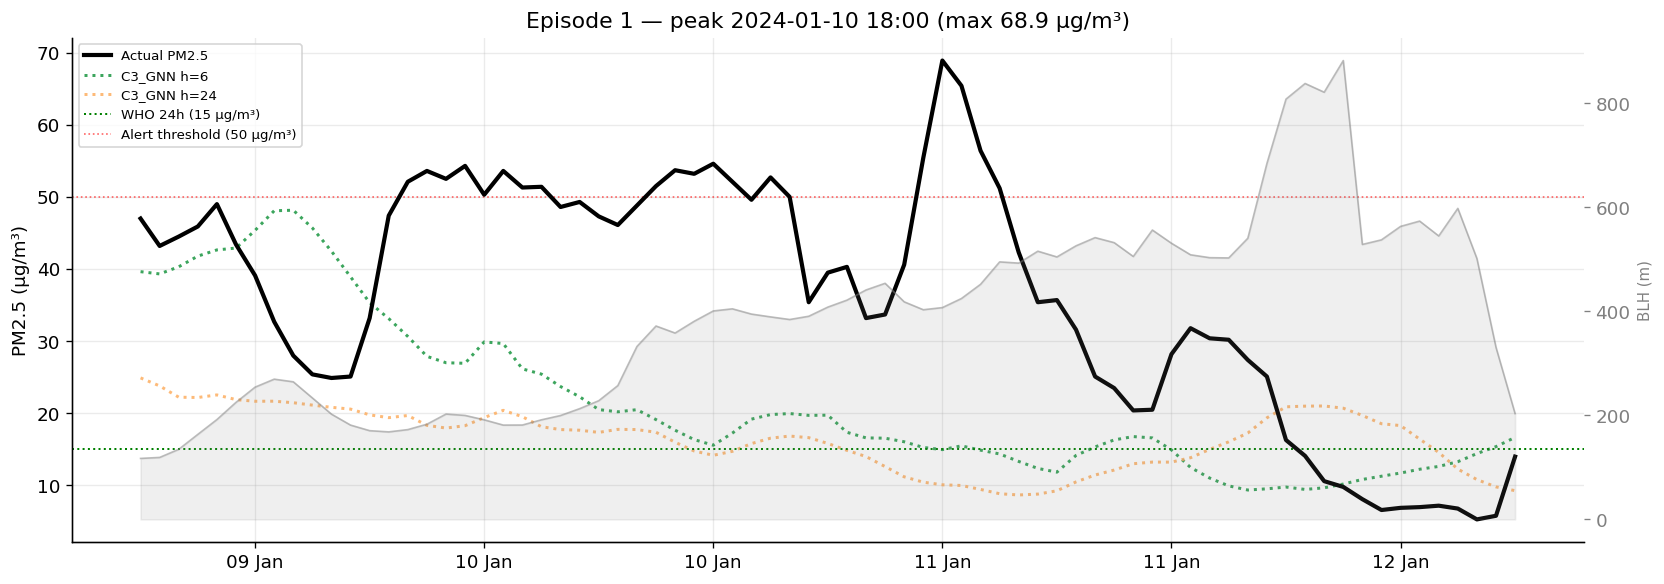

Episode 1 saved → D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_1.png


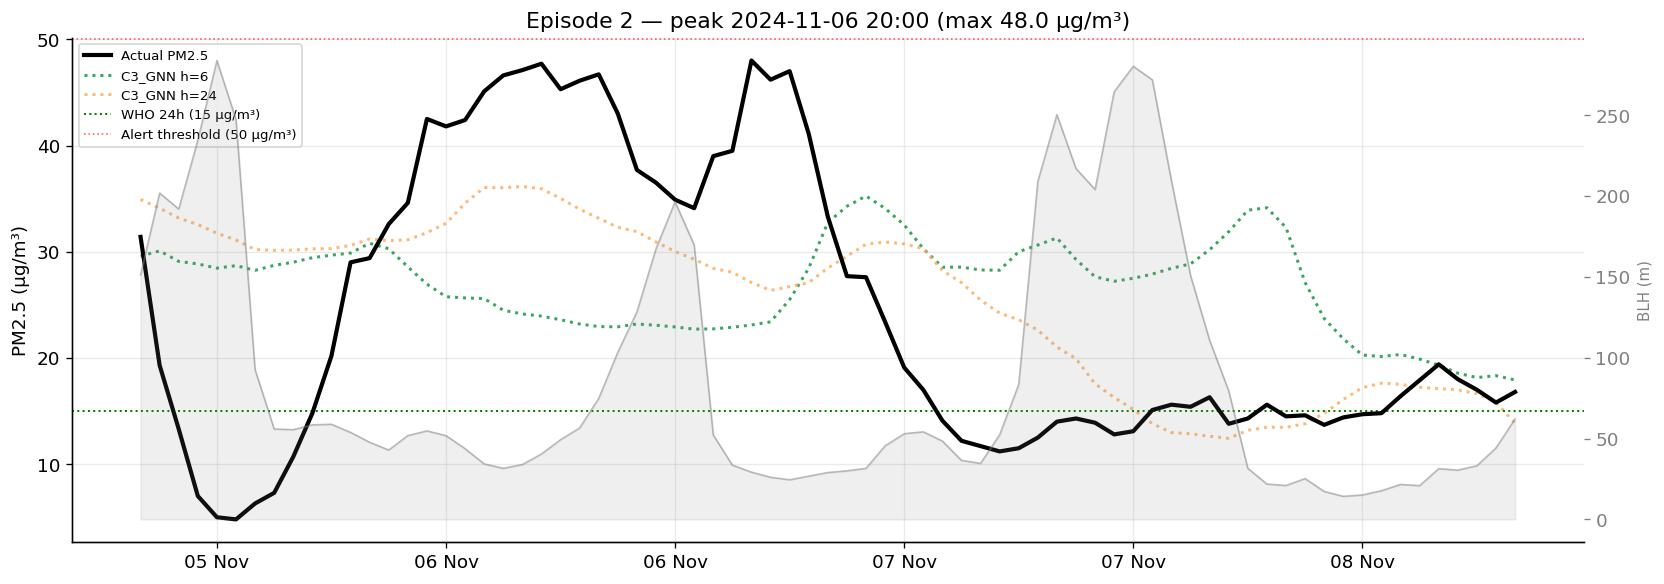

Episode 2 saved → D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_2.png


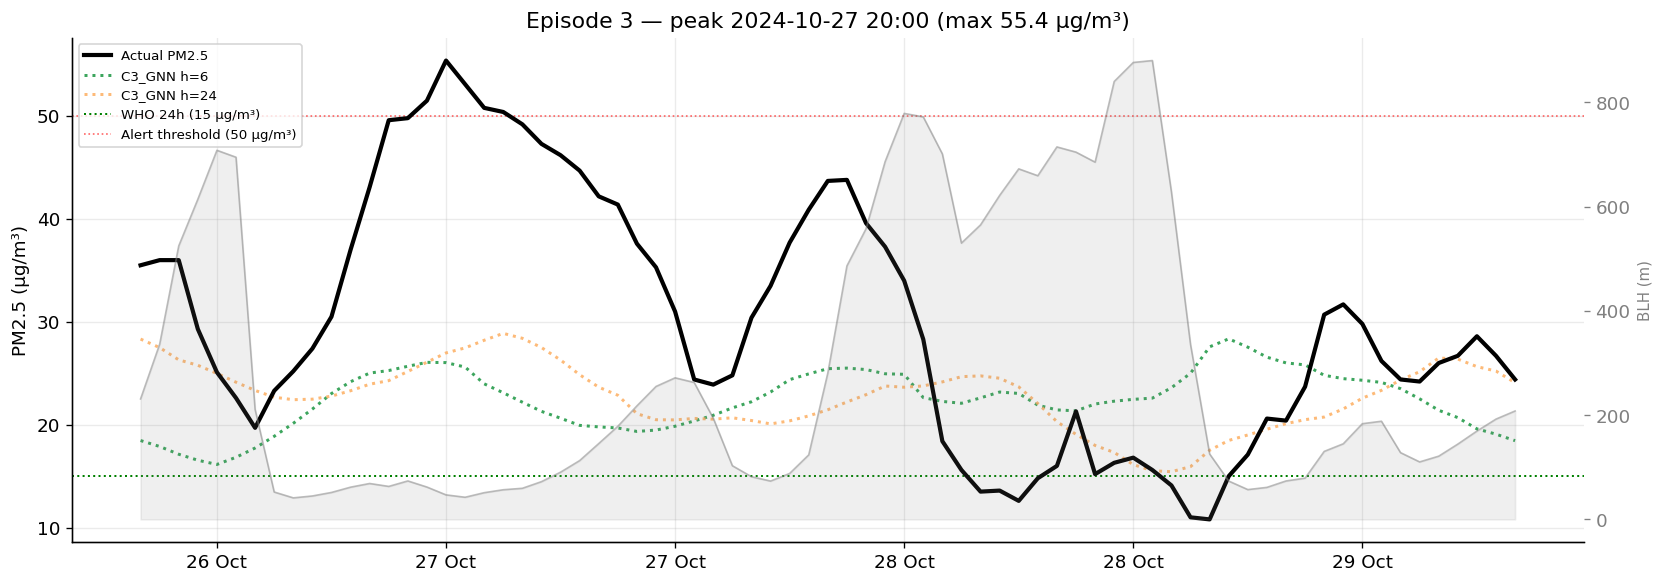

Episode 3 saved → D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_3.png


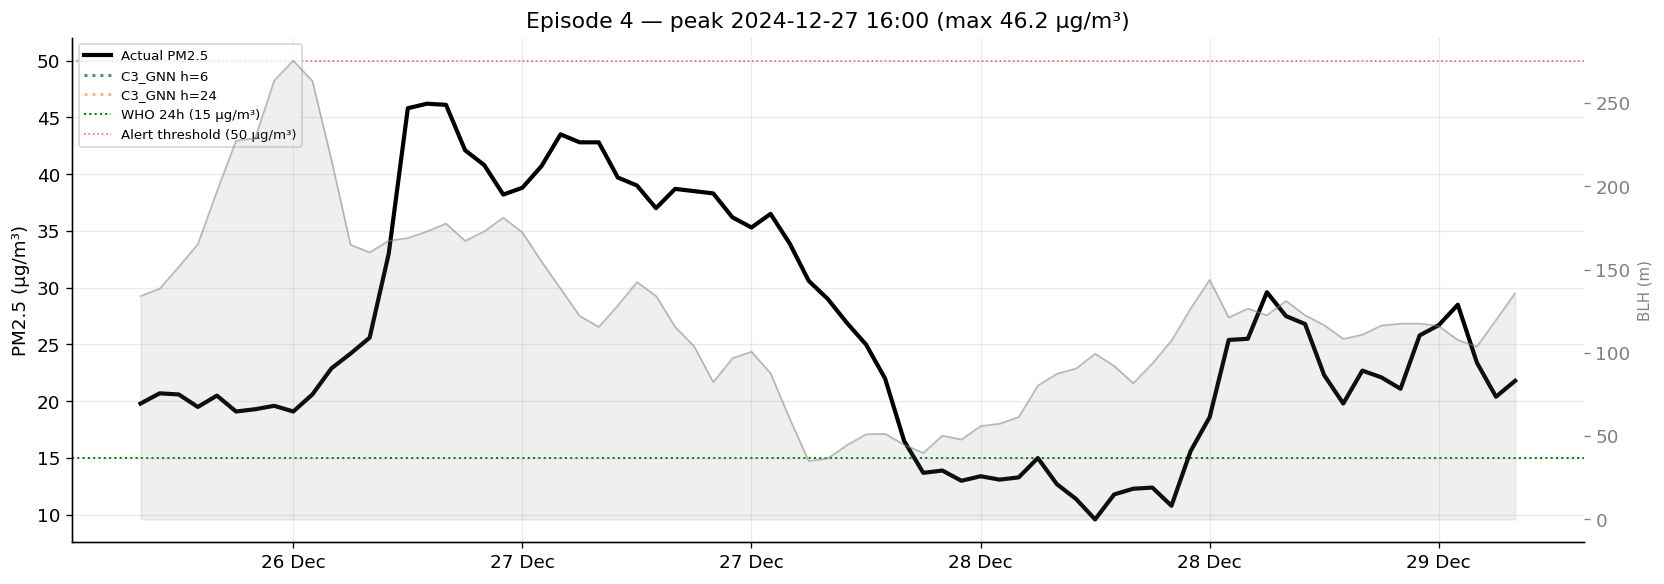

Episode 4 saved → D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_4.png


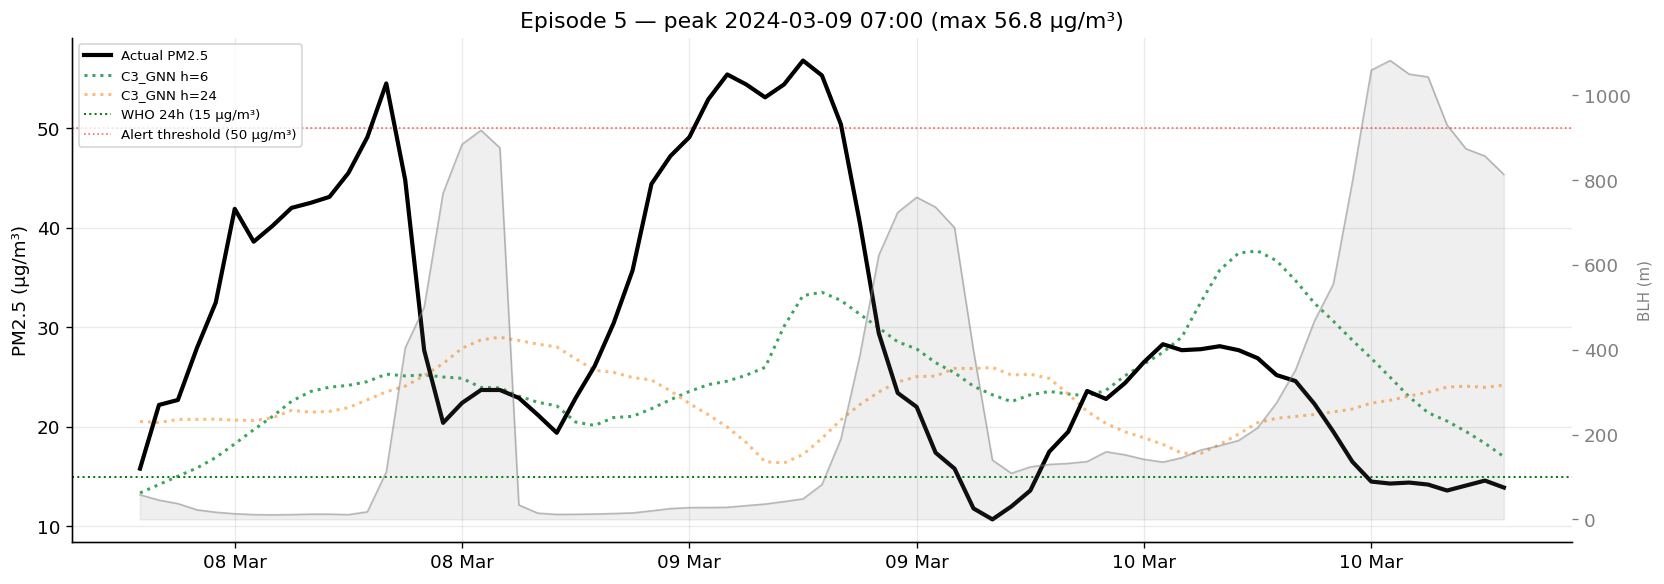

Episode 5 saved → D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_5.png


In [8]:
# ── Episode figures ───────────────────────────────────────────────────
summary_rows = []

for ep_i, peak in enumerate(episode_peaks, 1):
    start = peak - pd.Timedelta(hours=HALF)
    end   = peak + pd.Timedelta(hours=HALF)
    mask  = (test_df.index >= start) & (test_df.index <= end)

    actual = test_df.loc[mask, TARGET]
    blh    = test_df.loc[mask, 'blh'] if 'blh' in test_df.columns else None

    fig, ax = plt.subplots(figsize=(14, 5))

    # Actual PM2.5 (thick line)
    ax.plot(actual.index, actual.values, color='black', linewidth=2.5, label='Actual PM2.5', zorder=5)

    # C1_HGB predictions (dashed)
    for h, ls, color in [(6, '--', '#2c7bb6'), (24, '--', '#d7191c')]:
        if h in hgb_preds_by_h:
            ep_preds = hgb_preds_by_h[h].reindex(actual.index)
            ax.plot(ep_preds.index, ep_preds.values, linestyle=ls, color=color,
                    linewidth=1.8, label=f'C1_HGB h={h}', alpha=0.85)
            # Drop rows where either actual or prediction is NaN before computing metrics
            valid = actual.notna() & ep_preds.notna()
            if valid.any():
                m = compute_metrics(actual[valid].values, ep_preds[valid].values)
                summary_rows.append({'Episode': ep_i, 'Peak': peak, 'Model': 'C1_HGB_pfxf',
                                      'Horizon': h, **m,
                                      'max_obs': actual.max(), 'max_pred': ep_preds.max()})

    # B3_GNN predictions (dotted)
    for h, ls, color in [(6, ':', '#1a9641'), (24, ':', '#fdae61')]:
        if h in gnn_preds_by_h:
            ep_preds = gnn_preds_by_h[h].reindex(actual.index)
            ax.plot(ep_preds.index, ep_preds.values, linestyle=ls, color=color,
                    linewidth=1.8, label=f'C3_GNN h={h}', alpha=0.85)
            valid = actual.notna() & ep_preds.notna()
            if valid.any():
                m = compute_metrics(actual[valid].values, ep_preds[valid].values)
                summary_rows.append({'Episode': ep_i, 'Peak': peak, 'Model': 'C3_GNN',
                                      'Horizon': h, **m,
                                      'max_obs': actual.max(), 'max_pred': ep_preds.max()})

    # BLH on twin y-axis (muted)
    if blh is not None and blh.notna().any():
        ax2 = ax.twinx()
        ax2.fill_between(blh.index, blh.values, alpha=0.12, color='grey')
        ax2.plot(blh.index, blh.values, color='grey', linewidth=1.0, alpha=0.5, label='BLH')
        ax2.set_ylabel('BLH (m)', color='grey', fontsize=9)
        ax2.tick_params(axis='y', colors='grey')

    # WHO 24h reference line
    ax.axhline(WHO_24H_PM25, color='green', linestyle=':', linewidth=1.2,
               label=f'WHO 24h ({WHO_24H_PM25} µg/m³)')
    ax.axhline(ALERT_THRESHOLD, color='red', linestyle=':', linewidth=1.0,
               label=f'Alert threshold ({ALERT_THRESHOLD} µg/m³)', alpha=0.6)

    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'Episode {ep_i} — peak {peak.strftime("%Y-%m-%d %H:%M")} '
                 f'(max {actual.max():.1f} µg/m³)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.25)
    fig.tight_layout()

    save_path = episodes_dir / f'episode_{ep_i}.png'
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Episode {ep_i} saved → {save_path}')

In [9]:
# ── Summary table ─────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    print('\nEpisode × Model × Horizon summary:')
    print(summary_df[['Episode', 'Model', 'Horizon', 'MAE', 'MBE', 'max_obs', 'max_pred']].to_string(index=False))


# ── Onset detection ───────────────────────────────────────────────────
print('\n── Onset detection: predicting PM2.5 > 50 µg/m³ at least 6h in advance ──')
for ep_i, peak in enumerate(episode_peaks, 1):
    start = peak - pd.Timedelta(hours=HALF)
    end   = peak + pd.Timedelta(hours=HALF)
    mask  = (test_df.index >= start) & (test_df.index <= end)
    actual = test_df.loc[mask, TARGET]

    # Find the actual onset: first time PM2.5 rises above ALERT_THRESHOLD
    rising = actual[actual >= ALERT_THRESHOLD]
    if rising.empty:
        print(f'  Episode {ep_i}: PM2.5 never exceeds {ALERT_THRESHOLD} µg/m³ in window')
        continue
    actual_onset = rising.index[0]

    # Check each model/horizon: does it predict >= ALERT_THRESHOLD at least 6h before onset?
    for model_name, preds_dict in [('C1_HGB_pfxf', hgb_preds_by_h), ('C3_GNN', gnn_preds_by_h)]:
        for h in [6, 24]:
            if h not in preds_dict:
                continue
            p = preds_dict[h].reindex(actual.index)
            # Predictions that fire at least 6h before actual onset
            early_window = p[p.index <= actual_onset - pd.Timedelta(hours=6)]
            predicted_early = (early_window >= ALERT_THRESHOLD).any()
            status = 'YES' if predicted_early else 'no'
            print(f'  Episode {ep_i} | {model_name} h={h}: onset predicted >=6h early? {status}')


Episode × Model × Horizon summary:
 Episode  Model  Horizon     MAE      MBE  max_obs  max_pred
       1 C3_GNN        6 18.6676 -14.6450     68.9 48.151588
       1 C3_GNN       24 22.6148 -19.8857     68.9 24.911369
       2 C3_GNN        6 13.5944   2.5832     48.0 35.245125
       2 C3_GNN       24  8.5881   1.2333     48.0 36.138966
       3 C3_GNN        6 11.8117  -7.5567     55.4 28.350754
       3 C3_GNN       24  9.6287  -7.2061     55.4 28.882536
       5 C3_GNN        6 11.3268  -4.5956     56.8 37.666313
       5 C3_GNN       24 12.9372  -6.8875     56.8 29.004744

── Onset detection: predicting PM2.5 > 50 µg/m³ at least 6h in advance ──
  Episode 1 | C3_GNN h=6: onset predicted >=6h early? no
  Episode 1 | C3_GNN h=24: onset predicted >=6h early? no
  Episode 2: PM2.5 never exceeds 50 µg/m³ in window
  Episode 3 | C3_GNN h=6: onset predicted >=6h early? no
  Episode 3 | C3_GNN h=24: onset predicted >=6h early? no
  Episode 4: PM2.5 never exceeds 50 µg/m³ in window
  Epis